# 02 — Identity / Incidence Matrix `H_aug(t)`

`H_aug(t) = [ H_spatial(t) | H_lineage | H_functional | H_anastomosis(t) ]`

This notebook assembles the four hyperedge sources produced/used in notebook 01 into a single sparse incidence ("identity") matrix per timepoint, and visualizes its structure.

In [6]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, os.path.abspath('..'))

from dhgnn_lib.cell_universe import CellUniverse
from dhgnn_lib import hyperedges, incidence, visualization

RAW_DIR = '../raw_dataset'
OUTPUT_DIR = '../output_tables'

universe = CellUniverse.build(RAW_DIR, OUTPUT_DIR)
print(f'N = {len(universe)} cells')


N = 1625 cells


## 1. Load the hyperedge store

`HyperedgeStore` loads all four lookup tables and exposes the static lineage/functional hyperedge sets plus per-timepoint spatial/anastomosis sets.

In [7]:
store = hyperedges.HyperedgeStore(RAW_DIR, OUTPUT_DIR, universe)
print(f'lineage hyperedges (static):    {store.lineage().num_edges}')
print(f'functional hyperedges (static): {store.functional().num_edges}')
print(f'spatial/anastomosis timepoints:  {store.timepoints[0]}..{store.timepoints[-1]} '
      f'({len(store.timepoints)} timepoints with spatial communities)')


lineage hyperedges (static):    642
functional hyperedges (static): 4436
spatial/anastomosis timepoints:  15..190 (146 timepoints with spatial communities)


## 2. Assemble `H_aug(t)` for a sample timepoint

In [8]:
T_SAMPLE = 100
spatial = store.spatial(T_SAMPLE)
anastomosis = store.anastomosis(T_SAMPLE)
print(f'spatial hyperedges at t={T_SAMPLE}:     {spatial.num_edges}')
print(f'anastomosis hyperedges at t={T_SAMPLE}: {anastomosis.num_edges}')

batch = incidence.assemble(len(universe), spatial, store.lineage(), store.functional(), anastomosis)
print(f'H_aug(t={T_SAMPLE}): {batch.num_nodes} cells x {batch.num_edges} hyperedges, '
      f'nnz={batch.cell_index.shape[0]}')


spatial hyperedges at t=100:     27
anastomosis hyperedges at t=100: 12
H_aug(t=100): 1625 cells x 5117 hyperedges, nnz=15383


### What does `H_aug(t)` actually look like?

From two angles — what's **actually stored** (sparse) and what it **conceptually represents** (dense).

In [9]:
import numpy as np
np.set_printoptions(linewidth=200)

print('=== 1. What is ACTUALLY STORED — the sparse HyperedgeBatch fields ===')
print(f'num_nodes:        {batch.num_nodes}')
print(f'num_edges:        {batch.num_edges}')
print(f'cell_index shape: {tuple(batch.cell_index.shape)}  dtype={batch.cell_index.dtype}')
print(f'edge_index shape: {tuple(batch.edge_index.shape)}')
print(f'edge_type shape:  {tuple(batch.edge_type.shape)}')
print(f'edge_weight shape:{tuple(batch.edge_weight.shape)}')

print('\nFirst 10 nonzero entries (cell, hyperedge) pairs:')
edge_type_names = ['spatial', 'lineage', 'functional', 'anastomosis']
for i in range(10):
    c, e = batch.cell_index[i].item(), batch.edge_index[i].item()
    ename = edge_type_names[batch.edge_type[e].item()]
    print(f'  nnz[{i:2d}]: cell={universe.names[c]:14s} (idx {c:4d})  ->  edge {e:5d}  (type={ename})')

print('\n=== 2. What it CONCEPTUALLY REPRESENTS — a dense (cells x hyperedges) table ===')
dense = batch.to_dense()
nnz_fraction = (dense != 0).float().mean().item()
print(f'Dense shape: {tuple(dense.shape)}   nonzero fraction: {nnz_fraction:.5f} ({nnz_fraction*100:.2f}% filled)')

print('\nFirst 8 cells x first 12 hyperedges (mostly zero, as expected):')
print(dense[:8, :12].numpy())

print('\n=== 3. A row that actually has data — cell "ABa" ===')
abi = universe.get('ABa')
row = dense[abi]
nz = (row != 0).nonzero(as_tuple=True)[0]
print(f'cell ABa belongs to {len(nz)} hyperedges: {nz.tolist()}  (values: {row[nz].tolist()})')

=== 1. What is ACTUALLY STORED — the sparse HyperedgeBatch fields ===
num_nodes:        1625
num_edges:        5117
cell_index shape: (15383,)  dtype=torch.int64
edge_index shape: (15383,)
edge_type shape:  (5117,)
edge_weight shape:(5117,)

First 10 nonzero entries (cell, hyperedge) pairs:
  nnz[ 0]: cell=ABalaaap       (idx   20)  ->  edge     0  (type=spatial)
  nnz[ 1]: cell=ABalppaa       (idx  175)  ->  edge     0  (type=spatial)
  nnz[ 2]: cell=Cpapa          (idx  980)  ->  edge     0  (type=spatial)
  nnz[ 3]: cell=Cpapp          (idx  983)  ->  edge     0  (type=spatial)
  nnz[ 4]: cell=ABarpapa       (idx  357)  ->  edge     1  (type=spatial)
  nnz[ 5]: cell=Cpaaa          (idx  973)  ->  edge     1  (type=spatial)
  nnz[ 6]: cell=Cppaa          (idx  988)  ->  edge     1  (type=spatial)
  nnz[ 7]: cell=ABaraappap     (idx  270)  ->  edge     1  (type=spatial)
  nnz[ 8]: cell=ABarpppp       (idx  404)  ->  edge     2  (type=spatial)
  nnz[ 9]: cell=ABarappap      (idx  315) 

### Hyperedge composition by type

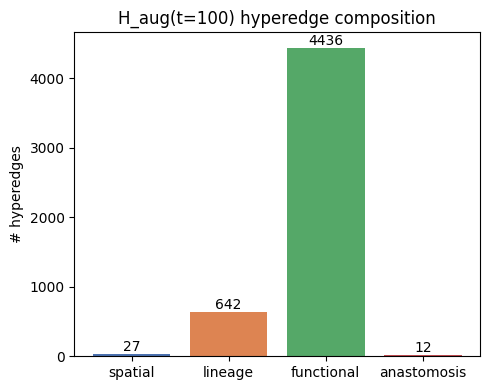

In [10]:
fig = visualization.plot_edge_type_counts(batch, title=f'H_aug(t={T_SAMPLE}) hyperedge composition')
plt.show()


### Incidence sparsity pattern

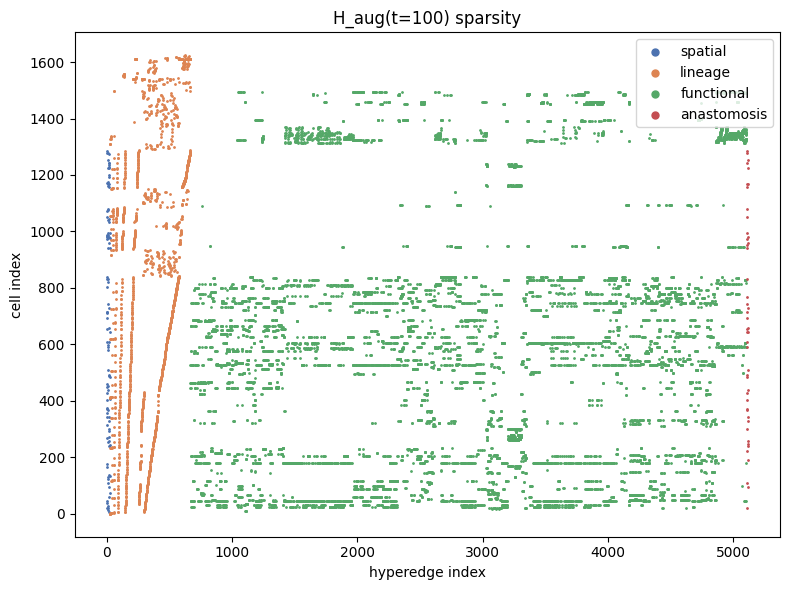

In [11]:
fig = visualization.plot_incidence_sparsity(batch, title=f'H_aug(t={T_SAMPLE}) sparsity')
plt.show()


## Summary

- `H_aug(t)` is assembled as a sparse `HyperedgeBatch` from 4 sources: spatial (dynamic, DBSCAN), lineage (static, 642 edges), functional (static, 4436 edges), anastomosis (dynamic).
- At t=100 this gives a ~1625 x ~5100 incidence matrix with a clear block structure by edge type.
- Next: **notebook 03** runs Hyper-SAGNN vertex convolution over `H_aug(t)`.